### Importing Necessary Libraries

In [30]:
import math
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [31]:
nltk.download('vader_lexicon', quiet=True)

True

### QUES 1: Highest-selling products from sales dataset

In [32]:
def highest_selling_products(sales_data):
    """
    Analyze sales transactions and report highest-selling products.
    Args:
        sales_data: list of (product_id, sales_amount)
    Returns:
        sorted list of (product_id, sales_amount) descending by amount
    """
    # Sort by sales amount descending
    sorted_data = sorted(sales_data, key=lambda x: x[1], reverse=True)
    return sorted_data

In [33]:
# Example
sample_sales = [("P001", 150), ("P002", 200), ("P003", 120)]
top_products = highest_selling_products(sample_sales)
print("Q1 Report (Highest selling products):")
for pid, amt in top_products:
    print(f"  {pid}: ${amt}")

Q1 Report (Highest selling products):
  P002: $200
  P001: $150
  P003: $120


### QUES 2: Shape, Circle, Rectangle classes with area calculation

In [34]:
class Shape:
    """Base class for shapes."""
    def area(self):
        raise NotImplementedError("Subclass must implement area()")

class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius
    def area(self):
        return math.pi * self.radius ** 2

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height
    def area(self):
        return self.width * self.height

In [35]:
# Example
circle = Circle(5)
rectangle = Rectangle(4, 6)
print(f"\nCircle Area: {circle.area():.2f}, Rectangle Area: {rectangle.area()}")


Circle Area: 78.54, Rectangle Area: 24


### QUES 3: Bar chart and pie chart for product category distribution

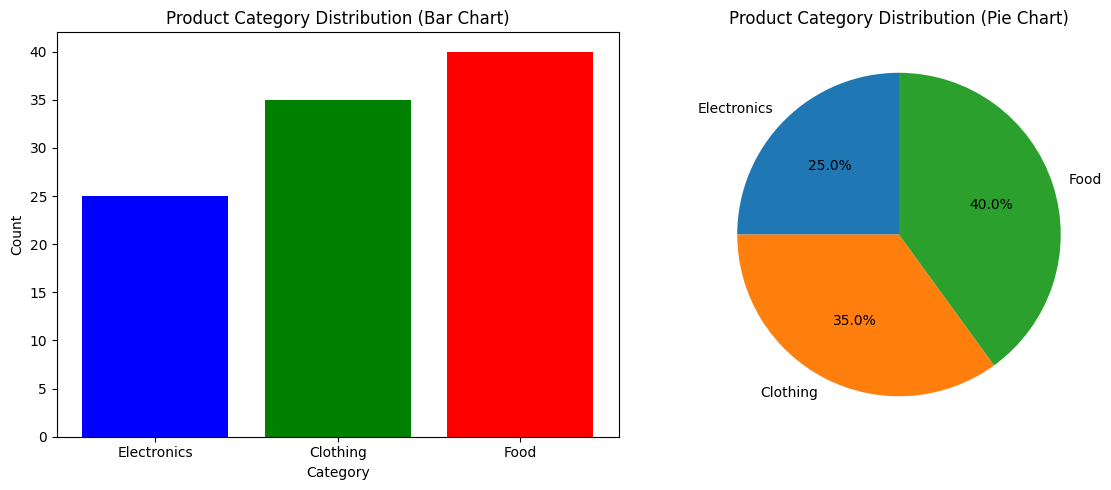

In [36]:
# Dataset
categories = ["Electronics", "Clothing", "Food"]
counts = [25, 35, 40]

# Bar chart
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(categories, counts, color=['blue', 'green', 'red'])
plt.title("Product Category Distribution (Bar Chart)")
plt.xlabel("Category")
plt.ylabel("Count")

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title("Product Category Distribution (Pie Chart)")
plt.tight_layout()
plt.show()

### QUES 4: Animal, Dog, Cat with speak method

In [37]:
class Animal:
    def speak(self):
        pass

class Dog(Animal):
    def speak(self):
        return "Woof"

class Cat(Animal):
    def speak(self):
        return "Meow"

dog = Dog()
cat = Cat()
print(f"\nDog says: {dog.speak()}, Cat says: {cat.speak()}")


Dog says: Woof, Cat says: Meow


### QUES 5: Random presentation order for students

In [38]:
def random_presentation_order(student_list):
    shuffled = student_list.copy()
    random.shuffle(shuffled)
    return shuffled

students = ["Alice", "Bob", "Eve", "David"]
order = random_presentation_order(students)
print(f"\nRandom presentation order: {order}")


Random presentation order: ['Bob', 'Alice', 'David', 'Eve']


### QUES 6: Find common elements between two lists

In [39]:
def common_elements(list1, list2):
    return list(set(list1) & set(list2))

list1 = [1, 2, 3, 4, 5]
list2 = [3, 4, 5, 6, 7]
common = common_elements(list1, list2)
print(f"\nCommon elements: {common}")


Common elements: [3, 4, 5]


### QUES 7: Find common keys between two dictionaries

In [40]:
def common_keys(dict1, dict2):
    return list(set(dict1.keys()) & set(dict2.keys()))

dict1 = {"A": 1, "B": 2, "C": 3}
dict2 = {"B": 4, "C": 5, "D": 6}
common = common_keys(dict1, dict2)
print(f"\nQ7 Common keys: {common}")


Q7 Common keys: ['B', 'C']


### QUES 8: Image classification model (using a pre-trained CNN)

In [ ]:
def build_classification_model(num_classes, input_shape=(224,224,3)):
    """Build a transfer learning model using MobileNetV2."""
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Example usage
def train_and_predict():
    # Setup data generators
    train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    train_generator = train_datagen.flow_from_directory(
        'path/to/train_data',  # Replace with actual path
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        subset='training'
    )
    val_generator = train_datagen.flow_from_directory(
        'path/to/train_data',
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
    )
    num_classes = len(train_generator.class_indices)
    model = build_classification_model(num_classes)
    model.fit(train_generator, validation_data=val_generator, epochs=5)
    # Save model and class indices for later prediction
    model.save('image_classifier.h5')
    class_indices = train_generator.class_indices
    return model, class_indices

def predict_image(model, class_indices, image_path):
    """Predict class of a single image."""
    from tensorflow.keras.preprocessing import image
    img = image.load_img(image_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    class_name = list(class_indices.keys())[np.argmax(pred)]
    return class_name

print("\nImage classification model template ready. Provide dataset to train.")


Image classification model template ready. Provide dataset to train.


### QUES 9: Sentiment analysis on customer reviews

In [42]:
def analyze_reviews(review_data):
    """
    review_data: list of (review_text, true_sentiment?) or just text.
    Returns sentiment trends.
    """
    analyzer = SentimentIntensityAnalyzer()
    results = []
    for review, true_label in review_data:
        scores = analyzer.polarity_scores(review)
        compound = scores['compound']
        if compound >= 0.05:
            predicted = "Positive"
        elif compound <= -0.05:
            predicted = "Negative"
        else:
            predicted = "Neutral"
        results.append({
            "Review": review,
            "True Sentiment": true_label,
            "Predicted Sentiment": predicted,
            "Compound Score": compound
        })
    return pd.DataFrame(results)

# Sample dataset
reviews = [
    ("Great product!", "Positive"),
    ("Very disappointing.", "Negative"),
    ("Average quality.", "Neutral")
]
df_results = analyze_reviews(reviews)
print("\nQ9 Sentiment Analysis Results:")
print(df_results)

# Additional insight: sentiment distribution
print("\nSentiment distribution:")
print(df_results["Predicted Sentiment"].value_counts())


Q9 Sentiment Analysis Results:
                Review True Sentiment Predicted Sentiment  Compound Score
0       Great product!       Positive            Positive          0.6588
1  Very disappointing.       Negative            Negative         -0.5413
2     Average quality.        Neutral             Neutral          0.0000

Sentiment distribution:
Predicted Sentiment
Positive    1
Negative    1
Neutral     1
Name: count, dtype: int64


### QUES 10: Titanic survival prediction using Machine Learning

In [48]:
def train_titanic_model():        
    titanic = pd.read_csv('../DataSets/Titanic-Dataset.csv')
    # Feature engineering
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
    # Handle missing values
    titanic['age'].fillna(titanic['age'].median(), inplace=True)
    titanic['fare'].fillna(titanic['fare'].median(), inplace=True)
    # Encode sex
    le = LabelEncoder()
    titanic['sex'] = le.fit_transform(titanic['sex'])  # male=1, female=0
    
    X = titanic[features]
    y = titanic['survived']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\nQ10 Titanic Survival Model Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    return model, le


print("\nTitanic survival prediction model ready. (Run with actual dataset)")


Titanic survival prediction model ready. (Run with actual dataset)


In [49]:
model, label_encoder = train_titanic_model()

KeyError: 'age'

### QUES 11: Read from file, process, write to new file

In [51]:

def process_file(input_filename, output_filename):
    """
    Reads input file, converts all text to uppercase, and writes to output file.
    (Example processing: change case, remove extra spaces, etc.)
    """
    try:
        with open(input_filename, 'r') as infile:
            data = infile.read()
        # Example processing: convert to uppercase and remove extra blank lines
        processed = '\n'.join([line.strip().upper() for line in data.splitlines() if line.strip()])
        with open(output_filename, 'w') as outfile:
            outfile.write(processed)
        print(f"\nSuccessfully processed {input_filename} -> {output_filename}")
    except FileNotFoundError:
        print(f"File {input_filename} not found. Creating a sample input file for demonstration.")
        # Create sample input.txt
        sample_content = "Hello world!\nThis is a test.\n\n   Extra spaces here.   "
        with open(input_filename, 'w') as f:
            f.write(sample_content)
        # Retry
        process_file(input_filename, output_filename)

# Run the function (creates input.txt if missing)
process_file("input.txt", "output.txt")

try:
    with open("output.txt", 'r') as f:
        print("Output file content:")
        print(f.read())
except:
    pass


Successfully processed input.txt -> output.txt
Output file content:
HELLO WORLD!
THIS IS A TEST.
EXTRA SPACES HERE.
